# Cell-type and spatial domains annotation

This notebook starts from an already pre-processed `AnnData` object (as if you already used Sopa) and uses [scConcept](https://github.com/theislab/scConcept) and [Novae](https://github.com/prism-oncology/novae) for postprocessing of real data.

> ℹ️ For the sake of this workshop, we already computed embeddings so that you can get started quickly. Indeed, running scConcept and Novae on a real-world slide would loose too much time for a workshop. Of course, feel free to check their documentation to know more about how to run them.


## Dependencies

We'll only need `novae`, and we'll use it to load pre-computed `scConcept` embeddings stored in our [Hugging Face organization](https://huggingface.co/prism-oncology).


In [ ]:
!pip install novae pyarrow

## Loading pre-computed embeddings


In [1]:
import novae

> ℹ️ Below, we use `[0]` because `novae.load_dataset` returns a list of slides. Here, we selected a slide by its name, so there is only one slide anyway.


In [2]:
adata = novae.load_dataset(
    pattern="Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE_outs",
    annotations=True,
    embeddings="corpus360M[multi-species]-model170M",
)[0]

[INFO] (novae.data._load.hf) Found 1 h5ad file(s) matching the filters.


We see that the following elements in the `AnnData` object:

1. Two novae keys in `.obs` with spatial domains at different resolutions: `novae_domains_res0.8`, `novae_domains_res1`
2. `X_scConcept` embeddings in `.obsm`
3. ⚠️ Pre-computed `cell_types` and `cell_type_level1`, but we will re-compute them using the scConcept embeddings.


In [3]:
adata

AnnData object with n_obs × n_vars = 275998 × 422
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'novae_sid', 'technology', 'name', 'cell_type', 'cell_type_level1', 'novae_domains_res0.8', 'novae_domains_res1'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'log1p', 'neighbors', 'novae_tissue', 'spatial_neighbors', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_scConcept'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'
    layers: 'counts', None (.X)

## Cell-level embedding usage

We already have scConcept embeddings, but we don't actually have cell-types. To do that, we can download a pre-annotated scRNAseq atlas (e.g., from [CELLxGENE](https://cellxgene.cziscience.com/)) for the right tissue/disease and get the corresponding scConcept embeddings.

> ℹ️ Here, we use scConcept, but we could use any foundation model that produces an embedding at the cell-level. This is not the case of Novae though, since it produces an embedding that represents a cell's neighborhood, not just the actual cell.

For this workshop, we extracted 1,000 cells from a colorectal reference and ran the same scConcept model as we used above. We can use load this pre-computed `AnnData` object as below:


In [4]:
import anndata as ad
from huggingface_hub import hf_hub_download

local_path = hf_hub_download(
    repo_id="prism-oncology/sandbox",
    filename="cirm_tutorials/crc_public_ref_subsample.h5ad",
    repo_type="dataset",
)

adata_ref = ad.read_h5ad(local_path)

We have again `X_scConcept` in `.obsm`:


In [5]:
adata_ref

AnnData object with n_obs × n_vars = 1000 × 16894
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_type_level1', 'cell_type_level2'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'gene_ids', 'gene'
    uns: 

And cell-type annotation at three different levels:


/Users/quentinblampey/miniforge3/envs/workshop2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)
/Users/quentinblampey/miniforge3/envs/workshop2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)
/Users/quentinblampey/miniforge3/envs/workshop2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs

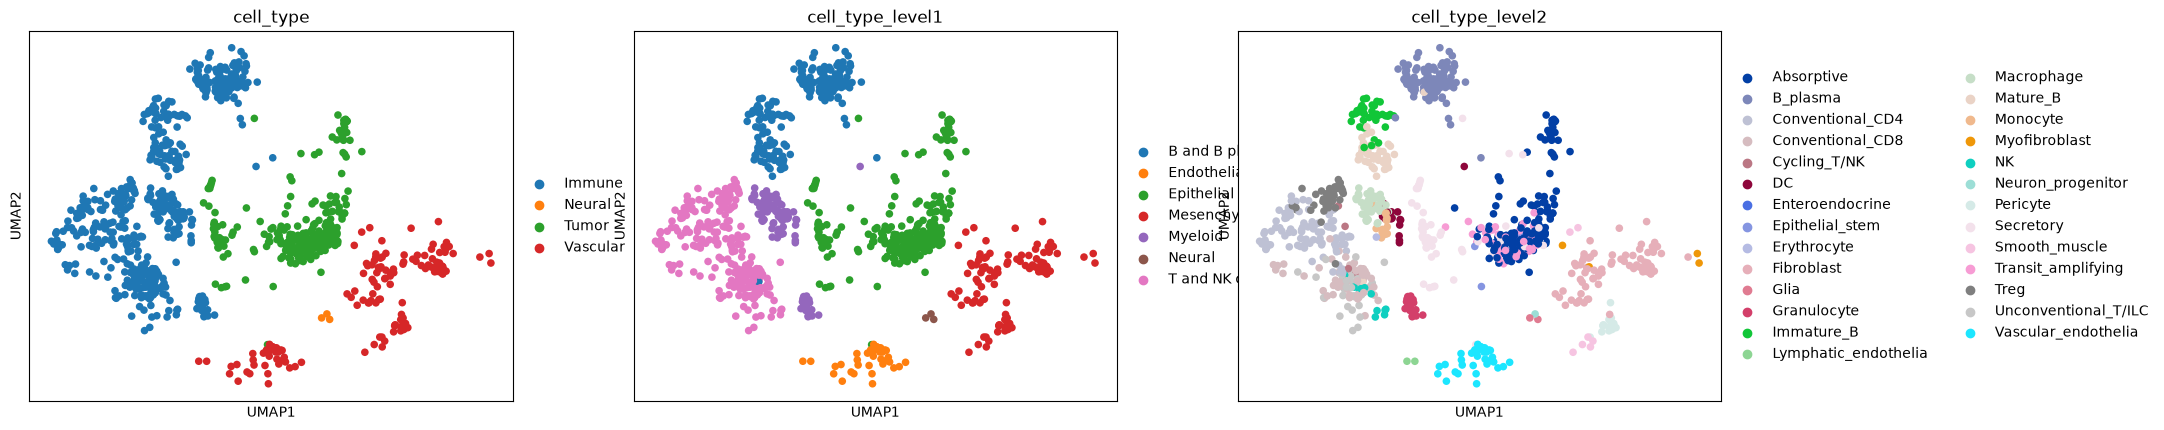

In [6]:
import scanpy as sc

sc.pl.umap(adata_ref, color=["cell_type", "cell_type_level1", "cell_type_level2"])

### Exercice A: Cell-type assignment

1. Fit a `kNN` using `sklearn` to assign cell-types of your reference `adata_ref` to your spatial object `adata`. Apply this to each level.
2. Does it converse the level hierarchy? If not, how to guarantee it?
3. Does it depend a lot on the number of cells from the reference? Note that, here, we subsetted the reference to only 1,000 cells.


In [7]:
from sklearn.neighbors import NearestNeighbors

In [9]:
n_neighbors = 3  # we don't have many cells...

nn = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean", algorithm="auto")
nn.fit(adata_ref.obsm["X_scConcept"])

_, indices = nn.kneighbors(adata.obsm["X_scConcept"])

In [10]:
import pandas as pd

df = pd.DataFrame(
    {
        i: adata_ref.obs["cell_type_level2"].iloc[indices[:, i]].values
        for i in range(indices.shape[1])
    }
)
df

,0,1,2
0,Conventional_CD8,Conventional_CD8,Conventional_CD8
1,Conventional_CD4,Conventional_CD4,Conventional_CD4
2,Conventional_CD4,Conventional_CD4,Conventional_CD4
3,Mature_B,Absorptive,Treg
4,Unconventional_T/ILC,Unconventional_T/ILC,Conventional_CD4
...,...,...,...
275993,Erythrocyte,DC,DC
275994,Transit_amplifying,B_plasma,Secretory
275995,Macrophage,Macrophage,Macrophage
275996,B_plasma,B_plasma,B_plasma


In [ ]:
# majority vote
adata.obs["new_cell_type_level2"] = df.mode(axis=1)[0].values

/Users/quentinblampey/miniforge3/envs/workshop2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


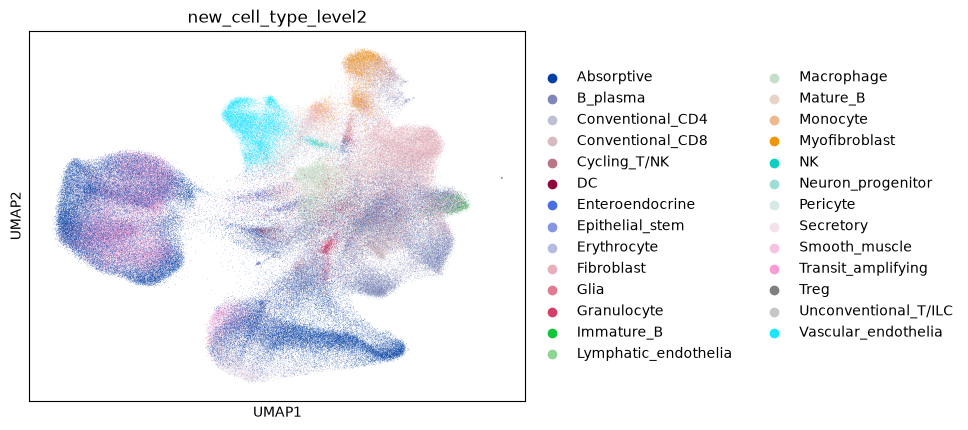

In [12]:
sc.pl.umap(adata, color="new_cell_type_level2")

There is a unique level1 parent per cell-type at level2:


In [13]:
adata_ref.obs.groupby("cell_type_level2")["cell_type_level1"].value_counts().unstack()

cell_type_level1,B and B plasma,Endothelial,Epithelial,Mesenchymal,Myeloid,Neural,T and NK cells
cell_type_level2,,,,,,,
Absorptive,0,0,159,0,0,0,0
B_plasma,141,0,0,0,0,0,0
Conventional_CD4,0,0,0,0,0,0,88
Conventional_CD8,0,0,0,0,0,0,64
Cycling_T/NK,0,0,0,0,0,0,4
DC,0,0,0,0,15,0,0
Enteroendocrine,0,0,1,0,0,0,0
Epithelial_stem,0,0,3,0,0,0,0
Erythrocyte,0,0,0,0,1,0,0


We use it as a mapping between levels.


In [14]:
mapping = adata_ref.obs.groupby("cell_type_level2")["cell_type_level1"].first()
adata.obs["new_cell_type_level1"] = adata.obs["new_cell_type_level2"].map(mapping)

mapping = adata_ref.obs.groupby("cell_type_level1")["cell_type"].first()
adata.obs["new_cell_type"] = adata.obs["new_cell_type_level1"].map(mapping)

/Users/quentinblampey/miniforge3/envs/workshop2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


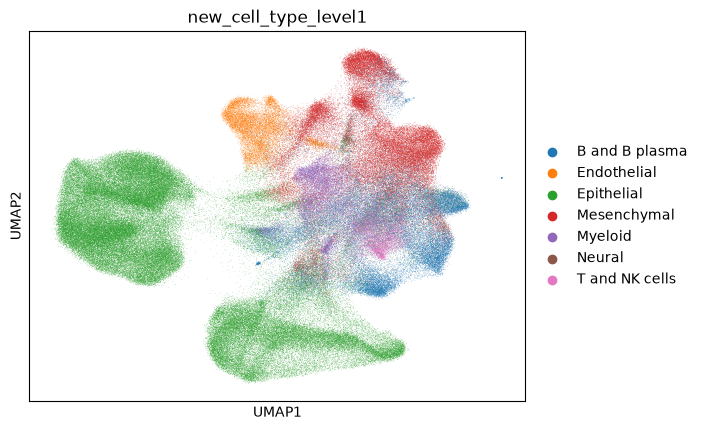

In [15]:
sc.pl.umap(adata, color="new_cell_type_level1")

We have very few cells in `adata_ref`, the agreement is not high...


In [16]:
(adata.obs["cell_type_level1"] == adata.obs["new_cell_type_level1"]).mean()

np.float64(0.853549663403358)

### Exercice B: gene expression inference

In the spatial `adata` object, we have only 422 genes.

1. Use a kNN to infer whole-genome expression. _Hint: for each spatial cell, you can pseudo-bulk its k-neirest-cells in the scConcept space get one expression vector._
2. Why is it using more memory per cell than the reference dataset?


In [37]:
from scipy.sparse import csr_matrix

X = adata_ref.layers["counts"]

coo = X[indices.flatten()].tocoo()

new_rows = coo.row // n_neighbors
X_inferred = csr_matrix(
    (coo.data, (new_rows, coo.col)), shape=(adata.n_obs, X.shape[1])
).tocsr()

In [38]:
from anndata import AnnData

adata_inferred = AnnData(X_inferred, var=adata_ref.var)

We have more features (non-zero genes) per cell in `adata_inferred` because we sum multiple neighbors:


In [39]:
adata_inferred.X.getnnz(axis=1).mean()

np.float64(2970.0758193899956)

In [40]:
adata_ref.X.getnnz(axis=1).mean()

np.float64(1311.39)

## Spatial domains

We already loaded Novae domains, we can show them spatially as below:


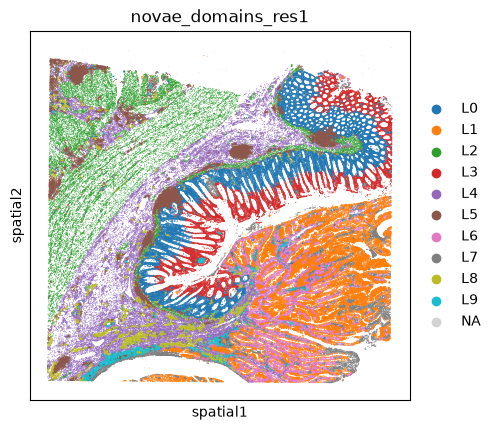

In [53]:
sc.pl.spatial(adata, color="novae_domains_res1", spot_size=15)

### Exercice C: labeling

1. Previously, we saw that we had two subtypes of Epithelial cells. Are they located in the same niches?
2. Extract features such as DEGs between domains, or cell-type percentage per domain.
3. Based on this, try to get (coarse) labels for each domain.

We see that the two subtypes of epithelial cells are healthy and tumor cells. More details on the [Novae tutorial](https://prism-oncology.github.io/novae/tutorials/labeling/).


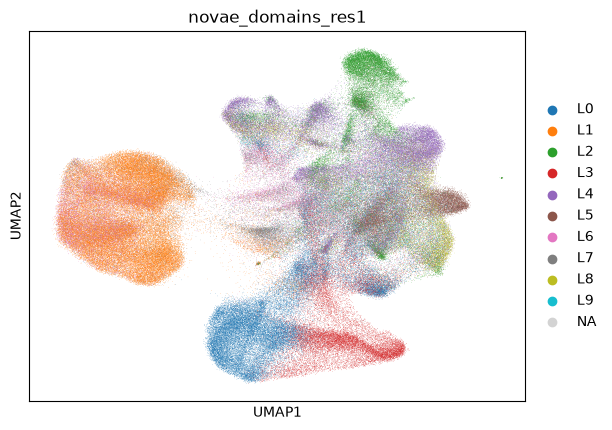

In [54]:
sc.pl.umap(adata, color="novae_domains_res1")